# di-PLS-1 benchmark: original covariance-penalty di-PLS

This notebook uses the local `dipals.py` and `functions.py` implementation of the original domain-invariant PLS algorithm. Source-domain labels are used for calibration and cross-validation. Target-domain adaptation uses only `X` from the target domain. The regularization parameter is determined by the built-in di-PLS heuristic (`heuristic=True`). Target-domain `ytest` is used only for final evaluation.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import scipy.io as sio
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt


def find_base_dir():
    cwd = Path.cwd()
    candidates = [cwd, cwd / "dipls_python", cwd.parent / "dipls_python"]
    for candidate in candidates:
        if (candidate / "dipals.py").exists() and (candidate / "functions.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from dipls_python or the project root.")


BASE_DIR = find_base_dir()
sys.path.insert(0, str(BASE_DIR))

import dipals as ml
#SOURCE_FILE = BASE_DIR / "wheatA1_20048.mat"
#TARGET_FILE = BASE_DIR / "wheatA3_48200.mat"
SOURCE_FILE = BASE_DIR / "nirshootout1.mat"
TARGET_FILE = BASE_DIR / "nirshootout2.mat"

LV_RANGE = range(1, 11)
CV_FOLDS = 10
RANDOM_STATE = 42

print(f"Base directory: {BASE_DIR}")

Base directory: e:\毕业论文\小论文\dipls_python


In [8]:
src = sio.loadmat(SOURCE_FILE)
tgt = sio.loadmat(TARGET_FILE)

X_src = np.asarray(src["X"], dtype=float)
y_src = np.asarray(src["y"], dtype=float).reshape(-1, 1)
X_src_test = np.asarray(src["Xtest"], dtype=float)
y_src_test = np.asarray(src["ytest"], dtype=float).reshape(-1, 1)

X_tgt_adapt = np.asarray(tgt["X"], dtype=float)
X_tgt_test = np.asarray(tgt["Xtest"], dtype=float)
y_tgt_test = np.asarray(tgt["ytest"], dtype=float).reshape(-1, 1)

print("Source train:", X_src.shape, y_src.shape)
print("Source test :", X_src_test.shape, y_src_test.shape)
print("Target adapt:", X_tgt_adapt.shape)
print("Target test :", X_tgt_test.shape, y_tgt_test.shape)

Source train: (200, 741) (200, 1)
Source test : (48, 741) (48, 1)
Target adapt: (48, 741)
Target test : (200, 741) (200, 1)


In [9]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    rmsep = rmse(y_true, y_pred)
    return {
        "rmsep": rmsep,
        "r2": float(r2_score(y_true, y_pred)),
        "rpd": float(np.std(y_true, ddof=1) / rmsep),
    }

In [10]:
def fit_heuristic_dipls(X_source, y_source, X_target_adapt, lv):
    model = ml.model(X_source, y_source, X_source, X_target_adapt, lv)
    model.fit(heuristic=True)
    return model, np.asarray(model.opt_l, dtype=float)


def cross_validated_rmsecv(X_source, y_source, X_target_adapt, lv, cv):
    fold_rmse = []
    for train_idx, val_idx in cv.split(X_source):
        model, _ = fit_heuristic_dipls(
            X_source[train_idx], y_source[train_idx], X_target_adapt, lv
        )
        y_val_pred, _ = model.predict(X_source[val_idx], rescale="Source")
        fold_rmse.append(rmse(y_source[val_idx], y_val_pred))
    return float(np.mean(fold_rmse)), float(np.std(fold_rmse, ddof=1))


def inflection_point_from_rmsecv(lv_values, rmsecv_values):
    lv_values = np.asarray(list(lv_values), dtype=float)
    rmsecv_values = np.asarray(rmsecv_values, dtype=float).reshape(-1)
    if rmsecv_values.size != lv_values.size:
        raise ValueError("lv_values and rmsecv_values must have the same length.")
    if rmsecv_values.size <= 2:
        return int(lv_values[np.argmin(rmsecv_values)]), np.zeros_like(rmsecv_values)

    points = np.column_stack([lv_values, rmsecv_values])
    start = points[0]
    end = points[-1]
    direction = end - start
    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        return int(lv_values[np.argmin(rmsecv_values)]), np.zeros_like(rmsecv_values)

    distances = np.abs(
        direction[0] * (points[:, 1] - start[1])
        - direction[1] * (points[:, 0] - start[0])
    ) / direction_norm
    if distances[1:-1].size == 0 or np.max(distances[1:-1]) <= 1e-12:
        return int(lv_values[np.argmin(rmsecv_values)]), distances

    best_idx = int(np.argmax(distances[1:-1]) + 1)
    return int(lv_values[best_idx]), distances

In [11]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print("di-PLS-1: regularization parameters are determined with heuristic=True.")
print(f"LV candidates: {list(LV_RANGE)}")

di-PLS-1: regularization parameters are determined with heuristic=True.
LV candidates: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [12]:
rows = []
for lv in LV_RANGE:
    rmsecv_mean, rmsecv_std = cross_validated_rmsecv(X_src, y_src, X_tgt_adapt, lv, cv)

    model, heuristic_lambdas = fit_heuristic_dipls(X_src, y_src, X_tgt_adapt, lv)
    y_target_pred, _ = model.predict(X_tgt_test, rescale="Target")
    y_source_pred, _ = model.predict(X_src_test, rescale="Source")

    target = regression_metrics(y_tgt_test, y_target_pred)
    source = regression_metrics(y_src_test, y_source_pred)
    rows.append({
        "method": "di-PLS-1",
        "lv": lv,
        "rmsecv": rmsecv_mean,
        "rmsecv_std": rmsecv_std,
        "target_rmsep": target["rmsep"],
        "target_r2": target["r2"],
        "target_rpd": target["rpd"],
        "source_rmsep": source["rmsep"],
        "source_r2": source["r2"],
        "source_rpd": source["rpd"],
        "heuristic_lambda_vector": ";".join(f"{v:g}" for v in heuristic_lambdas),
    })

lv_results = pd.DataFrame(rows).sort_values("lv").reset_index(drop=True)
selected_lv, elbow_distance = inflection_point_from_rmsecv(
    lv_results["lv"].to_numpy(), lv_results["rmsecv"].to_numpy()
)
results = lv_results.copy()
results["inflection_distance"] = elbow_distance
results["selected_by_inflection"] = results["lv"].eq(selected_lv)
results

,method,lv,rmsecv,rmsecv_std,target_rmsep,target_r2,target_rpd,source_rmsep,source_r2,source_rpd,heuristic_lambda_vector,inflection_distance,selected_by_inflection
0,di-PLS-1,1,1.937295,0.249570,1.762484,0.203435,1.123254,1.824672,0.221844,1.145614,1450.71,0.000000,False
1,di-PLS-1,2,1.823103,0.327418,1.747031,0.217342,1.133189,1.786166,0.254340,1.170311,1450.71;1870.32,0.065129,False
2,di-PLS-1,3,1.555040,0.156085,1.536908,0.394288,1.288117,1.393465,0.546174,1.500123,1450.71;1870.32;236.109,0.021170,False
3,di-PLS-1,4,1.301906,0.192072,1.294206,0.570486,1.529677,1.207714,0.659101,1.730848,1450.71;1870.32;236.109;99691.4,0.092775,False
4,di-PLS-1,5,0.968018,0.187818,1.025757,0.730189,1.930006,1.062799,0.736003,1.966854,1450.71;1870.32;236.109;99691.4;1.76368e+06,0.243854,False
5,di-PLS-1,6,0.585733,0.096312,0.725388,0.865069,2.729182,0.527091,0.935066,3.965858,1450.71;1870.32;236.109;99691.4;1.76368e+06;51...,0.442560,True
6,di-PLS-1,7,0.522822,0.099340,0.703250,0.873179,2.815095,0.459728,0.950603,4.546971,1450.71;1870.32;236.109;99691.4;1.76368e+06;51...,0.326965,False
7,di-PLS-1,8,0.472471,0.105089,0.683825,0.880088,2.895063,0.394781,0.963574,5.295017,1450.71;1870.32;236.109;99691.4;1.76368e+06;51...,0.199008,False
8,di-PLS-1,9,0.348002,0.072834,0.666547,0.886071,2.970107,0.279743,0.981710,7.472457,1450.71;1870.32;236.109;99691.4;1.76368e+06;51...,0.143992,False
9,di-PLS-1,10,0.313946,0.070214,0.638549,0.895442,3.100337,0.236156,0.986965,8.851651,1450.71;1870.32;236.109;99691.4;1.76368e+06;51...,0.000000,False


method                                                              di-PLS-1
lv                                                                         6
rmsecv                                                              0.585733
rmsecv_std                                                          0.096312
target_rmsep                                                        0.725388
target_r2                                                           0.865069
target_rpd                                                          2.729182
source_rmsep                                                        0.527091
source_r2                                                           0.935066
source_rpd                                                          3.965858
heuristic_lambda_vector    1450.71;1870.32;236.109;99691.4;1.76368e+06;51...
inflection_distance                                                  0.44256
selected_by_inflection                                                  True

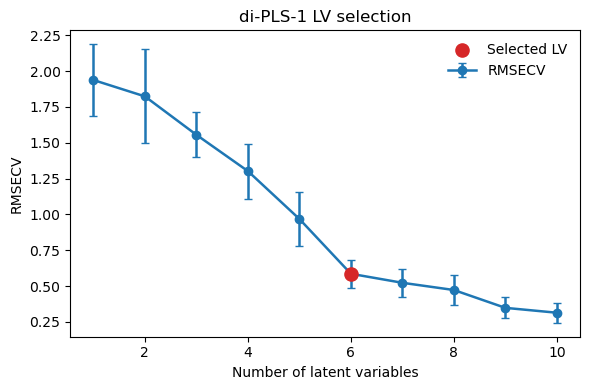

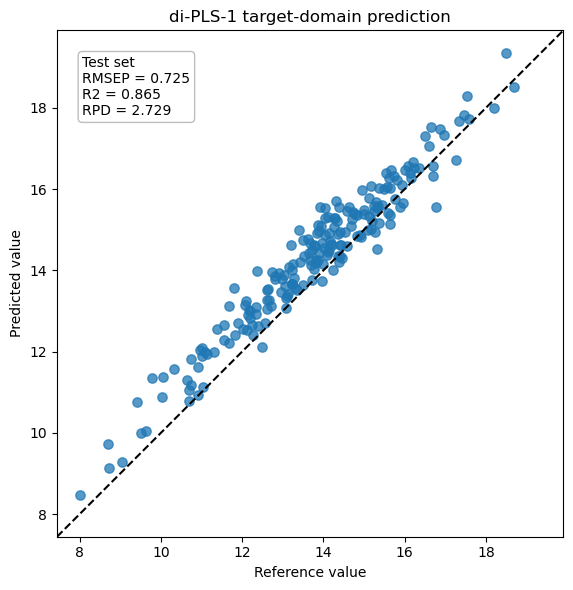

In [13]:
selected = results.loc[results["selected_by_inflection"]].iloc[0]
selected_lv = int(selected["lv"])

final_model, selected_lambdas = fit_heuristic_dipls(X_src, y_src, X_tgt_adapt, selected_lv)
y_pred, _ = final_model.predict(X_tgt_test, rescale="Target")

print(selected)

plt.figure(figsize=(6, 4))
plt.errorbar(
    results["lv"], results["rmsecv"], yerr=results["rmsecv_std"],
    fmt="o-", capsize=3, linewidth=1.8, markersize=6, label="RMSECV"
)
plt.scatter([selected_lv], [selected["rmsecv"]], s=90, color="tab:red", zorder=3, label="Selected LV")
plt.xlabel("Number of latent variables")
plt.ylabel("RMSECV")
plt.title("di-PLS-1 LV selection")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_tgt_test, y_pred, s=45, alpha=0.75)
ax = plt.gca()
metric_text = (
    "Test set\n"
    f"RMSEP = {selected['target_rmsep']:.3f}\n"
    f"R2 = {selected['target_r2']:.3f}\n"
    f"RPD = {selected['target_rpd']:.3f}"
)
ax.text(
    0.05, 0.95, metric_text,
    transform=ax.transAxes,
    va="top", ha="left",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.7", "alpha": 0.85},
    fontsize=10,
)
axis_min = float(min(y_tgt_test.min(), y_pred.min()))
axis_max = float(max(y_tgt_test.max(), y_pred.max()))
margin = 0.05 * (axis_max - axis_min)
axis_min -= margin
axis_max += margin
plt.plot([axis_min, axis_max], [axis_min, axis_max], "k--", linewidth=1.5)
plt.xlabel("Reference value")
plt.ylabel("Predicted value")
plt.title("di-PLS-1 target-domain prediction")
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()